In [2]:
import sys
sys.path.insert(0, '..')

from utils.evaluation import (
    load_and_evaluate_cnnlstm_model
)
from utils.preprocessing import (
    load_cicids2017_data,
    load_ciciot2023_data,
)
import pandas as pd

In [3]:
# =========================
# Config: Define datasets
# =========================
df_cicids2017 = load_cicids2017_data()
df_ciciot2023 = load_ciciot2023_data()

In [1]:
FEATURES = [
    "proto",
    "service",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "conn_state",
    "missed_bytes",
    "history",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
    "orig_pkt_rate",
    "orig_byte_rate",
    "pkt_asymmetry",
    "byte_asymmetry",
    "time_elapsed",
    "flood_rate",
    "uniqDstPorts",
    "pktsPerPort",
    "scanDuration",
    "uniqSrcIPs",
    "failRatio",
]
TARGET_LABELS = ["BENIGN", "DOS_HTTP_FLOOD", "PORTSCAN"]

In [5]:
def add_portscan_attack_features(df: pd.DataFrame, window_seconds: float = 5.0) -> pd.DataFrame:
    df = df.copy()

    # label cleanup
    df["label"] = df["label"].astype(str).str.strip().str.upper()
    df = df[df["label"].isin(TARGET_LABELS)].copy()

    # PORTSCAN features
    df["window_id"] = (df["ts"] // window_seconds).astype(int)

    group_cols = ["id.orig_h", "window_id"]

    agg = df.groupby(group_cols).agg(
        uniqDstPorts=("id.resp_p", "nunique"),
        totalOrigPkts=("orig_pkts", "sum"),
        scanDuration=("duration", "max"),
        uniqSrcIPs=("id.orig_h", "nunique"),
        totalFlows=("id.orig_h", "size"),
    ).reset_index()

    FAILED_STATES = {"S0", "REJ", "RSTO", "RSTR", "RSTOS0", "RSTRH", "SH", "SHR"}
    df["is_failed_conn"] = df["conn_state"].astype(str).isin(FAILED_STATES).astype(int)

    fail_agg = df.groupby(group_cols).agg(
        failedFlows=("is_failed_conn", "sum"),
    ).reset_index()

    agg = agg.merge(fail_agg, on=group_cols, how="left")
    agg["failedFlows"] = agg["failedFlows"].fillna(0.0)

    agg["pktsPerPort"] = agg["totalOrigPkts"] / agg["uniqDstPorts"].clip(lower=1)
    agg["failRatio"] = agg["failedFlows"] / agg["totalFlows"].clip(lower=1)

    df = df.merge(
        agg[
            [
                "id.orig_h",
                "window_id",
                "uniqDstPorts",
                "pktsPerPort",
                "scanDuration",
                "uniqSrcIPs",
                "failRatio",
            ]
        ],
        on=["id.orig_h", "window_id"],
        how="left",
    )

    return df

In [9]:
df_cicids2017 = add_portscan_attack_features(df_cicids2017)
df_ciciot2023 = add_portscan_attack_features(df_ciciot2023)

In [10]:
label_column = "label"
def split_features_and_target(df):
    X = df[FEATURES].copy()
    y_df = df[df[label_column].isin(TARGET_LABELS)]
    y = y_df[label_column]
    return X, y

X_cicids, y_cicids = split_features_and_target(df_cicids2017)
X_ciciot, y_ciciot = split_features_and_target(df_ciciot2023)

Evaluation for CICIoT2023-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties tested on CICIDS2017:

=== CICIoT2023-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties tested on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.9939    0.9354    0.9638    625030
DOS_HTTP_FLOOD     0.9301    0.9793    0.9541    154769
      PORTSCAN     0.8411    0.9974    0.9126    154034

      accuracy                         0.9529    933833
     macro avg     0.9217    0.9707    0.9435    933833
  weighted avg     0.9581    0.9529    0.9537    933833


=== Per-Label Accuracy ===

BENIGN: 0.9354
DOS_HTTP_FLOOD: 0.9793
PORTSCAN: 0.9974


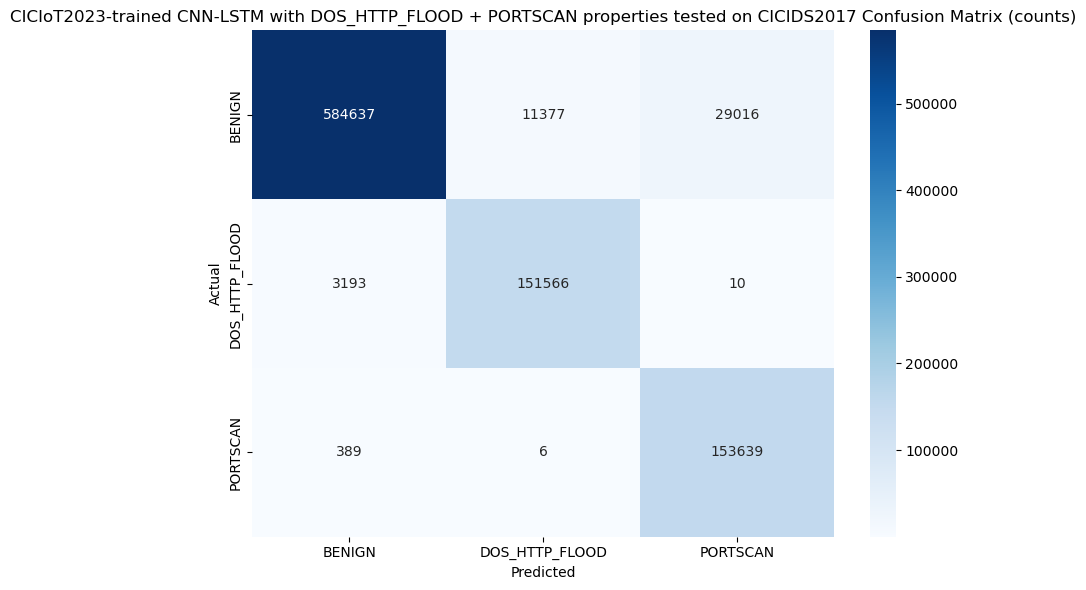

In [11]:
# Load CICIoT2023 model and evaluate on CICIDS2017
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_ciciot2023_multiclass.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties tested on CICIDS2017"
)

Evaluation for CICIDS2017-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties tested on CICIoT2023:

=== CICIDS2017-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1889    0.9784    0.3167    342255
DOS_HTTP_FLOOD     0.9998    0.0843    0.1555   1508589
      PORTSCAN     0.9040    0.6996    0.7888    216533

      accuracy                         0.2968   2067377
     macro avg     0.6976    0.5874    0.4203   2067377
  weighted avg     0.8555    0.2968    0.2485   2067377


=== Per-Label Accuracy ===

BENIGN: 0.9784
DOS_HTTP_FLOOD: 0.0843
PORTSCAN: 0.6996


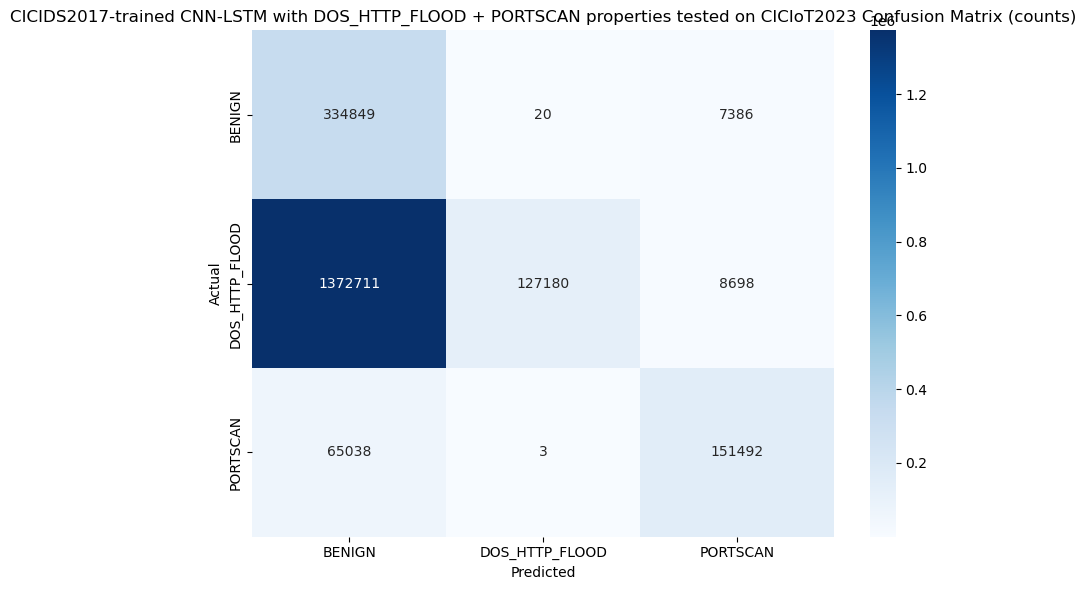

In [12]:
# Load CICIDS2017 model and evaluate on CICIoT2023
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_cicids2017_multiclass.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties tested on CICIoT2023"
)